In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

In [3]:
r0 = pd.read_csv("res0.csv")
r1 = pd.read_csv("res1.csv")
r2 = pd.read_csv("res2.csv")
r3 = pd.read_csv("res3.csv")
r4 = pd.read_csv("res4.csv")

# merge all results into one dataframe
df = pd.concat([r0, r1, r2, r3, r4], ignore_index=True)

In [4]:
df_mod = pd.DataFrame()
df_mod["first"] = [row[0] for row in df['won'].apply(ast.literal_eval)]
df_mod["second"] = [row[1] for row in df['won'].apply(ast.literal_eval)]
df_mod["third"] = [row[2] for row in df['won'].apply(ast.literal_eval)]
df_mod["fourth"] = [row[3] for row in df['won'].apply(ast.literal_eval)]
df_mod["fifth"] = [row[4] for row in df['won'].apply(ast.literal_eval)]
df_mod['p_0'] = [row[0] for row in df['points'].apply(ast.literal_eval)]
df_mod['p_1'] = [row[1] for row in df['points'].apply(ast.literal_eval)]
df_mod['p_2'] = [row[2] for row in df['points'].apply(ast.literal_eval)]
df_mod['p_3'] = [row[3] for row in df['points'].apply(ast.literal_eval)]
df_mod['p_4'] = [row[4] for row in df['points'].apply(ast.literal_eval)]

In [5]:
df_mod["fifth"].mode()

0    1
Name: fifth, dtype: int64

In [6]:
df_agg = pd.DataFrame()
players = ["play_random", "greedy", "rule", "mcts_short", "mcts_long"]
for p_id in range(len(players)):
    norm_points = sum([(row[p_id]-min(row))/(max(row)-min(row))  for row in df['points'].apply(ast.literal_eval)])
    avg_points = sum([row[p_id] for row in df['points'].apply(ast.literal_eval)])/len(df)
    df_agg[players[p_id]] = [norm_points, avg_points]

In [7]:
df_agg

,play_random,greedy,rule,mcts_short,mcts_long
0,530.154517,30.595171,959.589668,645.307876,711.116477
1,41.130000,3.701000,71.994000,49.151000,53.824000


In [8]:
df_mod["first"].value_counts()

first
2    737
4    139
3     78
0     45
1      1
Name: count, dtype: int64

Text(0.5, 1.0, 'Počet vítězství')

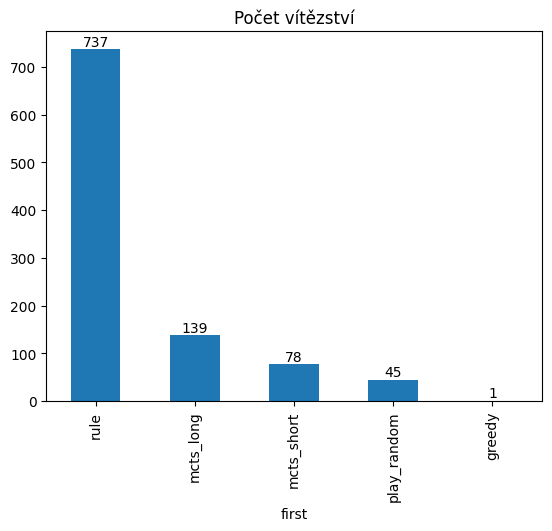

In [9]:
p_map = {0: "play_random", 1: "greedy", 2: "rule", 3: "mcts_short", 4: "mcts_long"}
df_mod["first"].map(p_map).value_counts().plot(kind="bar")
# add numbers on top of bars
for i, (key, value) in enumerate(df_mod["first"].map(p_map).value_counts().items()):
    plt.text(i, value, str(value), ha='center', va='bottom')
plt.title("Počet vítězství")


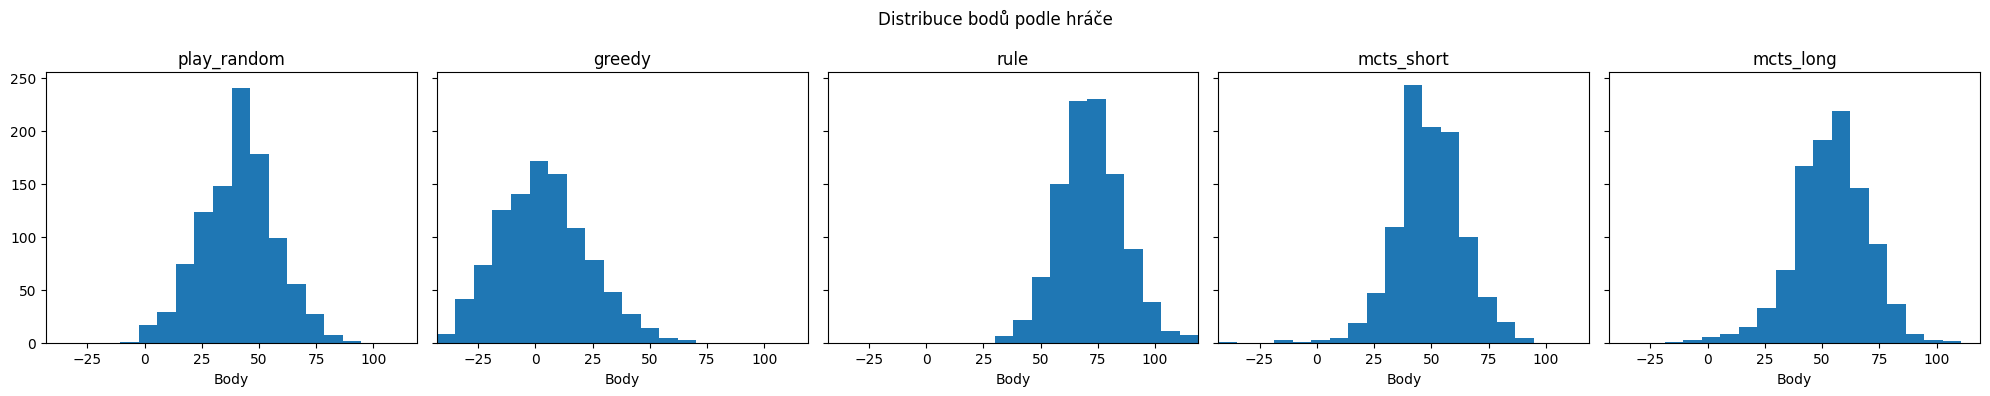

In [10]:

cols = [f"p_{i}" for i in range(5)]
global_min = df_mod[cols].min().min()
global_max = df_mod[cols].max().max()

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for i, ax in enumerate(axes):
    col = f"p_{i}"
    player_name = p_map[i]
    
    ax.hist(df_mod[col], bins=20, range=(global_min, global_max))
    ax.set_title(player_name)
    ax.set_xlabel("Body")
    
    ax.set_xlim(global_min, global_max)

plt.suptitle("Distribuce bodů podle hráče")
plt.tight_layout()
plt.show()

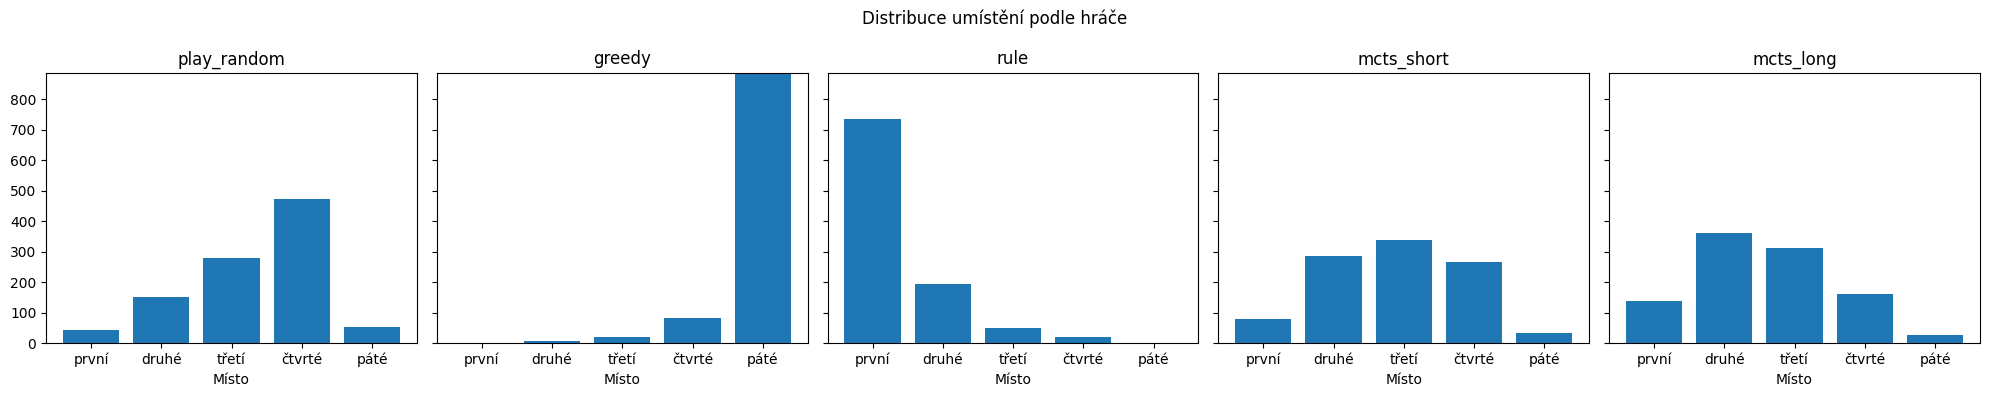

In [11]:
places = ["first", "second", "third", "fourth", "fifth"]
places_cz = ["první", "druhé", "třetí", "čtvrté", "páté"] 

num_players = 5  
fig, axes = plt.subplots(1, num_players, figsize=(20, 4), sharey=True)

max_count = 0
for i in range(num_players):
    counts = [(df_mod[place] == i).sum() for place in places]
    max_count = max(max_count, max(counts))

for i, ax in enumerate(axes):
    player_name = p_map[i]
    counts = [(df_mod[place] == i).sum() for place in places]
    
    ax.bar(places_cz, counts) 
    ax.set_title(player_name)
    ax.set_xlabel("Místo")
    ax.set_ylim(0, max_count) 

plt.suptitle("Distribuce umístění podle hráče")
plt.tight_layout()
plt.show()

In [17]:
from numpy import var


for col in ["p_0", "p_1", "p_2", "p_3", "p_4"]:
    max_points = max(df_mod[col])
    min_points = min(df_mod[col])
    avg_points = sum(df_mod[col])/len(df_mod[col])
    vr = var(df_mod[col])
    print(f"{col}: max={max_points}, min={min_points}, avg={avg_points}", f"var={vr}")

p_0: max=92, min=-3, avg=41.13 var=264.95709999999997
p_1: max=70, min=-43, avg=3.701 var=366.28959900000007
p_2: max=119, min=31, avg=71.994 var=189.817964
p_3: max=91, min=-39, avg=49.151 var=221.716199
p_4: max=109, min=-12, avg=53.824 var=258.247024


In [13]:
short_10_50 = pd.read_csv('out.csv')
short_2_250 = pd.read_csv('out1.csv')
short_5_100 = pd.read_csv('out2.csv')
shorts = [short_10_50, short_2_250, short_5_100]

In [14]:
long_10_25 = pd.read_csv('long0.csv')
long_2_125 = pd.read_csv('long1.csv')
long_5_50 = pd.read_csv('long2.csv')
longs = [long_10_25, long_2_125, long_5_50]

0.898
63.72
0.762
57.206
0.746
57.348


Text(0.5, 1.0, 'Procento výher modelu typu short podle hyperparametrů')

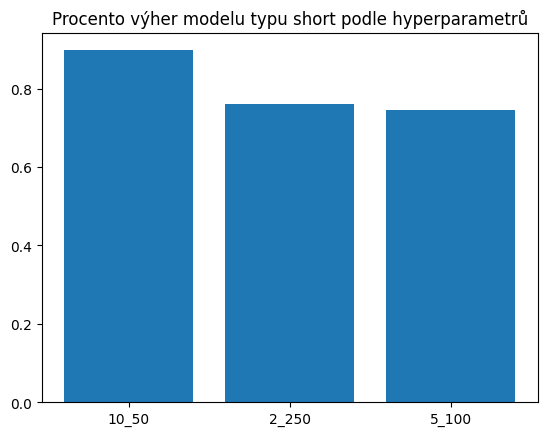

In [15]:
for sh in shorts:
    print(sum(sh['won']/len(sh)))
    print(sh['points'].mean())

plt.bar(['10_50', '2_250', '5_100'], [sum(sh['won']/len(sh)) for sh in shorts])
plt.title('Procento výher modelu typu short podle hyperparametrů') 

401
59.518
369
57.002
386
58.736


Text(0.5, 1.0, 'Procento výher modelu typu long podle hyperparametrů')

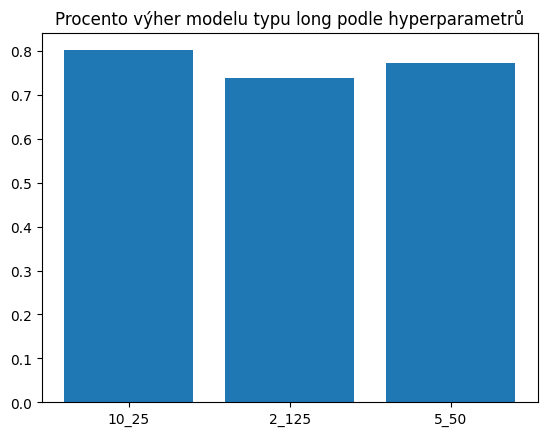

In [16]:
for sh in longs:
    print(sum(sh['won']))
    print(sh['points'].mean())

plt.bar(['10_25', '2_125', '5_50'], [sum(sh['won']/len(sh)) for sh in longs])
plt.title('Procento výher modelu typu long podle hyperparametrů')   
